<a href="https://colab.research.google.com/github/ArielaLevkov/ImageProcessing_TA/blob/main/recitations/08_BinaryImages_ImageProcessingRecitation_Skeletonized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import os
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL

In [26]:
GITHUB_PATH = 'https://raw.githubusercontent.com/ArielaLevkov/ImageProcessing_TA/main/images/'

def read_file(fname:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        fname: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_path = os.path.join(file_path, fname)
    response = requests.get(file_path)
    fp = BytesIO(response.content)

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [27]:
def plot_images(img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
    axes[0].imshow(img1,  cmap='gray')
    axes[1].imshow(img2,  cmap='gray')

<div dir="rtl">

# 8. Binary Skeletonize Images (מציאת שלד של אובייקט)
<dir>

<div dir="rtl">

* בשיעור הקודם למדנו: Connected Components - איך לזהות אובייקטים בתמונה בינארית.
* במשימות של זיהוי אובייקטים (Object Recognition), כמו זיהוי פנים, חשוב לאפיין כל אובייקט לפי מאפיינים ייחודיים.
* אחת הדרכים לייצג אובייקט היא לתאר אותו באמצעות סט של תכונות (Features).
* השלד (Skeleton) הוא אחת התכונות הללו והוא מספק ייצוג קומפקטי של הצורה.
<dir>

<div dir="rtl">

## 8.1 Medial Axis Transform (MAT)
<dir>

<div dir="rtl">

### הגדרה:
הציר המרכזי (Medial Axis) של קבוצה
$S$, אשר תחומה על-ידי עקומה מישורית
$C$, הוא קבוצת כל מרכזי המעגלים שנוגעים בעקומה
$C$ בשתי נקודות או יותר,
כאשר כל המעגלים האלה נמצאים בשלמותם בתוך
$S$.
<dir>

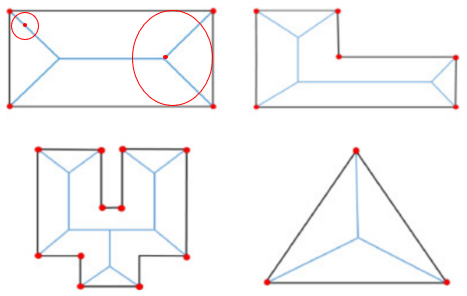

<div dir="rtl">

### סרטון לדוגמה:

https://www.youtube.com/watch?v=uBzveKQt18s


<div dir="rtl">

## 8.2 הדגמה של MAT ע"י פונקציות מובנות:
<dir>

In [41]:
from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert

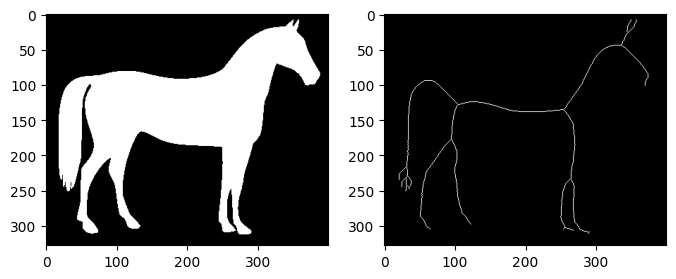

In [30]:
image = invert(data.horse())
skeleton = medial_axis(image)
plot_images(image, skeleton)

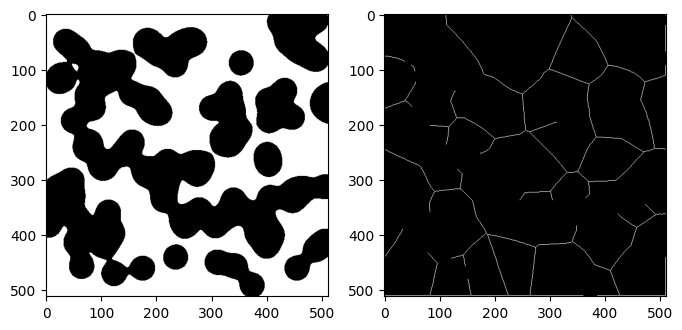

In [31]:
image = invert(data.binary_blobs())
skeleton = medial_axis(image)
plot_images(image, skeleton)

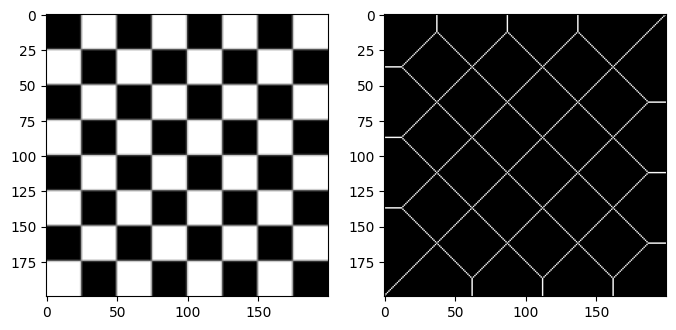

In [32]:
image = invert(data.checkerboard())
skeleton = medial_axis(image)
plot_images(image, skeleton)

<div dir="rtl">

## 8.3 Skeletonize אלגוריתם:
* יצירת מטריצת מרחק ע"י שימוש בשכנות של 4 שכנים
* סימון פקסלי שלד - פיקסל הוא שלד אם הוא גדול או שווה ל4 שכניו
<dir>


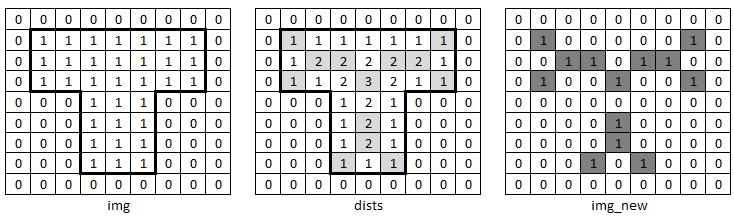

<div dir="rtl">

### שלב ראשון - יצירת מטריצת מרחק:


<dir>

```python
- Input: img: binary image
- dist = 0; dists = img.copy(); dist_changed = True
- while dist_changed:
   - dist = dist + 1
   - dist_changed = False
   - scan img
      - if img[r,c] == 0:
         - continue
      - if min(neighbours(r,c)) >= dist:
         - dists[r,c] = dist + 1
         - dist_changed = True
```

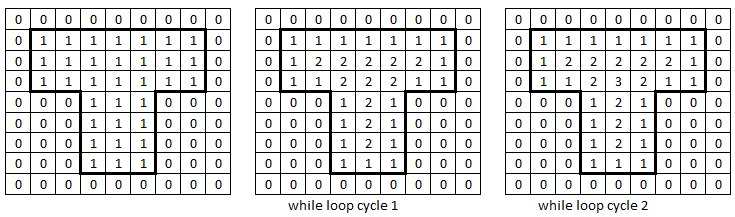

<div dir="rtl">

### שלב שני - סימון פקסלי שלד:

<dir>

```python
- Input: dists:
- img_new = dists.copy();
- scan dists;
    - if dists[r,c] > 0 && dists[r,c] >= all neighbours(r,c):
         - img_new[r,c] = 1;
```

<div dir="rtl">

### בעיות נפוצות בMAT:
* קיימת אי רציפות בשלד
* פינות פנימיות יוצרות ערכים גבוהים ולא רציפים
* מסדרונות צרים וסימטריים ייהפכו לשלד עבה
<dir>

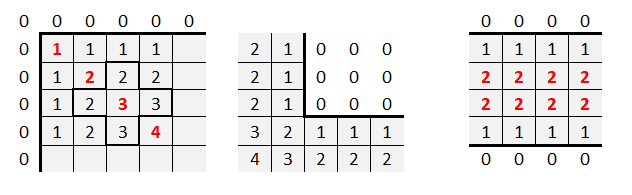

<div dir="rtl">

##8.4 שאלות:
1. איזה סוגי צורות של אובייקטים מתאימים ביותר לייצוג באמצעות שלד?
2. מה השלד של עיגול?
3. האם לכל אובייקט יש שלד יחיד?
<dir>

<div dir="rtl">

### 4. האם כל שלד מייצג אובייקט מסויים אחד?
<dir>

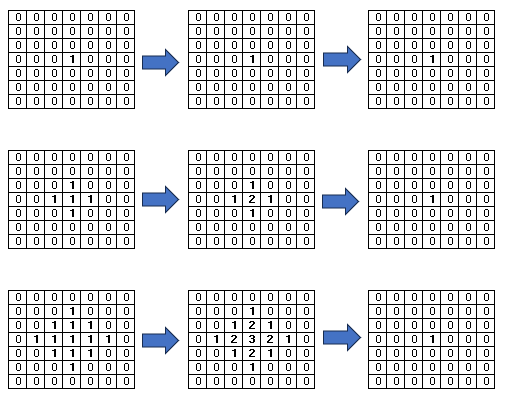

<div dir="rtl">

4. איזה תוספת יכולה להפוך שלד לייחודי?
5. איזו תוספת נחוצה כדי שנוכל לשחזר את האובייקט המקורי מהשלד, כלומר שMAT תיהיה הפיכה?
<dir>

<div dir="rtl">

### 6.  האם השלד יציב לשינויים (באובייקט עצמו)?
<dir>

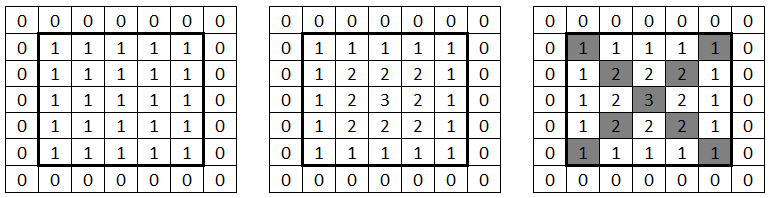

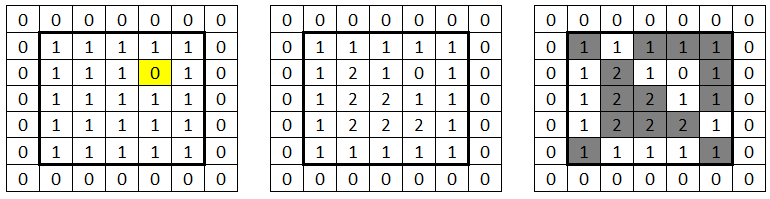

<div dir="rtl">

### שחזור תמונה ע"י שלד ומפת מרחקים:
<dir>

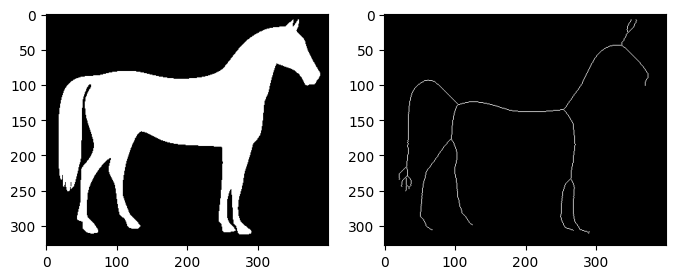

In [55]:
from skimage.draw import disk
img_1 = invert(data.horse())
skeleton, dist = medial_axis(img_1, return_distance=True)
masked = dist.copy()
plot_images(img_1, skeleton)

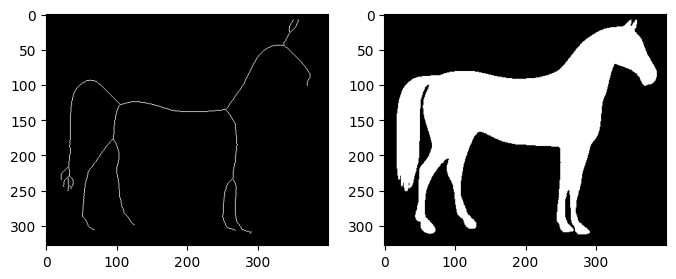

In [56]:
reconstructed = np.zeros_like(img_1, dtype=bool)

for r in range(img_1.shape[0]):
    for c in range(img_1.shape[1]):
        if skeleton[r, c]:
            radius = dist[r, c]
            rr, cc = disk((r, c), radius)
            reconstructed[rr, cc] = True

plot_images(skeleton, reconstructed)


<div dir="rtl">

## 8.5 דוגמה לשימוש באלגוריתם יותר מדוייק:
<dir>

<div dir="rtl">

### MAT רגיל:
<dir>

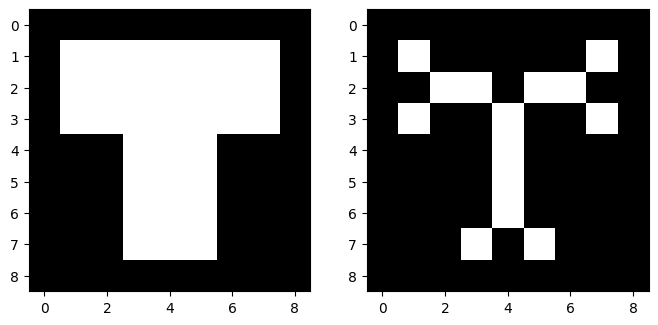

In [58]:
img2 = np.array([[0,0,0,0,0,0,0,0,0],
                 [0,1,1,1,1,1,1,1,0],
                 [0,1,1,1,1,1,1,1,0],
                 [0,1,1,1,1,1,1,1,0],
                 [0,0,0,1,1,1,0,0,0],
                 [0,0,0,1,1,1,0,0,0],
                 [0,0,0,1,1,1,0,0,0],
                 [0,0,0,1,1,1,0,0,0],
                 [0,0,0,0,0,0,0,0,0],
                 ])
skeleton = medial_axis(img2)
plot_images(img2, skeleton)

<div dir="rtl">

### skeletonize:

* משתמש בדילול מורפולוגי (Morphological Thinning).

* מסיר בהדרגה פיקסלים מהגבול ללא פגיעה בקישוריות.

* חוזר עד שהאובייקט נהיה בעובי פיקסל אחד בלבד.

* מבוסס על בדיקת שכנים ולא על חישובי מרחקים כמו MAT.

* מפיק שלד יציב, דק ורציף.
<dir>

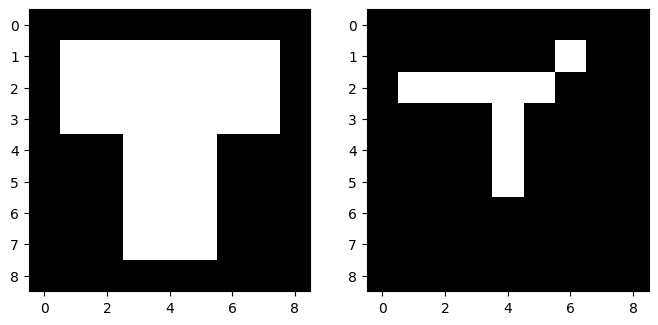

In [59]:
skeleton = skeletonize(img2)
plot_images(img2, skeleton)